# Experiment 5: K-Nearest Neighbors

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** KNN Classification with optimal K selection  
**Dataset:** `iris.csv (Iris flower — 150 samples, 4 features, 3 species)`  
**Lab Book Reference:** §9 K Nearest Neighbors, page 38–43

---

## 🎯 Objective

Implement **K-Nearest Neighbors** classification on the Iris dataset. We tune the hyperparameter K (number of neighbours) by sweeping K = 1…20 and selecting the value that maximises test accuracy. We also visualise the **decision boundary** in 2-D using petal length and petal width.

## ▶️ How to Run This Notebook

> **Option A — Google Colab (recommended if you don't have Python locally):**
> 1. Upload the entire `ML-Lab-Activities-Complete` folder to your Google Drive
>    (so it appears at `My Drive/ML-Lab-Activities-Complete/`).
> 2. In Colab, `File → Open notebook → Google Drive → 05-K-Nearest-Neighbors/05_*.ipynb`.
> 3. The first code cell auto-mounts Drive, chdir's to this experiment folder,
>    and creates an `outputs/` subfolder for every figure.
>
> **Option B — Local Jupyter:**
> ```bash
> # 1. (optional) create a virtual-env
> python -m venv .venv && source .venv/bin/activate
>
> # 2. install dependencies (one-time)
> pip install -r requirements.txt
>
> # 3. launch Jupyter from the repository root
> jupyter notebook 05-K-Nearest-Neighbors/05_*.ipynb
> ```
>
> **Option C — Headless execution:**
> ```bash
> jupyter nbconvert --to notebook --execute \
>   05-K-Nearest-Neighbors/05_*.ipynb \
>   --output executed.ipynb
> ```

Datasets are read from `../datasets/` (relative to the notebook's folder).
Generated figures are **auto-saved** to `./outputs/` inside this experiment's folder.


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Adjust this path if you placed the folder elsewhere in your Drive
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '05-K-Nearest-Neighbors'))
    print(f'Running in Google Colab. Changed CWD to: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

# Create outputs/ folder in this experiment's directory
OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Auto-save every matplotlib figure to outputs/ ---
# We patch plt.show() so that BEFORE a figure is shown, it is also saved
# to the outputs/ folder.  In the Jupyter inline backend, plt.show() is
# essentially a no-op (display happens automatically at cell-end), but it
# is still called inside every plotting cell — so this is the right hook.
import matplotlib.pyplot as plt

_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    # Save every currently-open figure before showing
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('✅ Setup complete.')
print(f'   Datasets will be read from: {os.path.join(os.getcwd(), "..", "datasets")}')
print(f'   Figures will be auto-saved to: {OUTPUT_DIR}')


Running locally. CWD: /home/z/my-project/work/final/05-K-Nearest-Neighbors


✅ Setup complete.
   Datasets will be read from: /home/z/my-project/work/final/05-K-Nearest-Neighbors/../datasets
   Figures will be auto-saved to: /home/z/my-project/work/final/05-K-Nearest-Neighbors/outputs


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
import warnings; warnings.filterwarnings('ignore')
print("Libraries imported.")


Libraries imported.


## 2. Load & Explore Dataset

In [3]:
data = pd.read_csv('../datasets/iris.csv')

print(f"Shape: {data.shape}")
display(data.head())

print("\nSpecies counts:")
print(data['species'].value_counts())

print("\nStatistics:")
display(data.describe().round(2))


Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Species counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## 3. Check for Null Values

In [4]:
print("Null values:")
print(data.isnull().sum())
print("\n✅ No missing values." if data.isnull().sum().sum() == 0 else "⚠ Handle missing values.")


Null values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

✅ No missing values.


## 4. Pairplot — Visualise Feature Relationships

A pairplot reveals how separable the species are in each pair of features. *Iris setosa* is
linearly separable from the other two species; *versicolor* and *virginica* overlap somewhat.


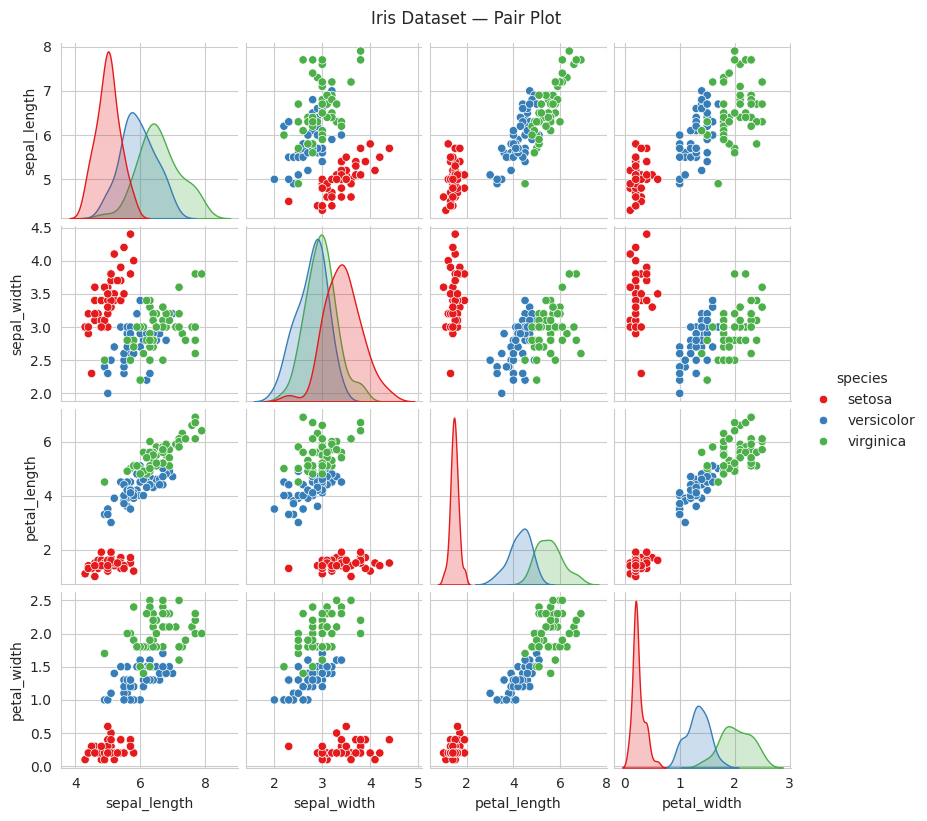

In [5]:
sns.pairplot(data, hue='species', height=2.0, palette='Set1')
plt.suptitle('Iris Dataset — Pair Plot', y=1.02)
plt.show()


## 5. Define Features and Target

In [6]:
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = data[feature_cols]
y = data['species']

# Encode species labels to integers for compatibility
le = LabelEncoder()
y_encoded = le.fit_transform(y)
species_names = le.classes_

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Species: {list(species_names)}")


X shape: (150, 4)
y shape: (150,)
Species: ['setosa', 'versicolor', 'virginica']


## 6. Split Data (80/20)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (120, 4), Test: (30, 4)


## 7. Feature Scaling

KNN is **distance-based** — features with larger magnitudes would dominate the Euclidean
distance. We standardise all features.


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Features standardised.")


Features standardised.


## 8. Find the Optimal K

We sweep K = 1…20 and record test accuracy. The **elbow** of the curve indicates a good K
(large enough to be robust, small enough to capture local structure).


,K,Train Accuracy,Test Accuracy
0,1,1.0000,0.9667
1,2,0.9667,0.9333
2,3,0.9583,0.9333
3,4,0.9583,0.9333
4,5,0.9750,0.9333
5,6,0.9583,0.9333
6,7,0.9750,0.9667
7,8,0.9583,0.9333
8,9,0.9583,0.9667
9,10,0.9583,0.9667



🏆 Best K = 1 with test accuracy = 0.9667


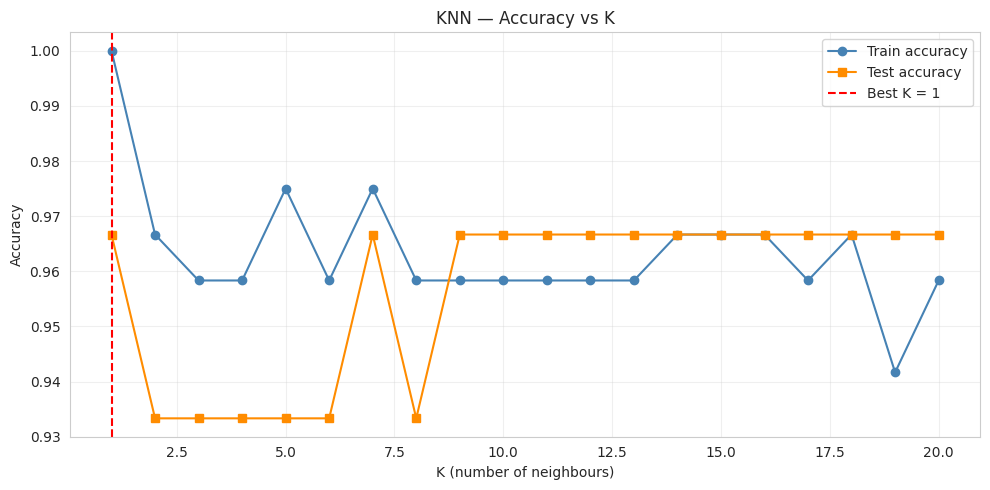

In [9]:
k_range = range(1, 21)
train_acc, test_acc = [], []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    knn.fit(X_train_scaled, y_train)
    train_acc.append(knn.score(X_train_scaled, y_train))
    test_acc.append(knn.score(X_test_scaled,  y_test))

results_df = pd.DataFrame({
    'K': list(k_range),
    'Train Accuracy': train_acc,
    'Test Accuracy' : test_acc,
}).round(4)
display(results_df)

best_k = k_range[int(np.argmax(test_acc))]
print(f"\n🏆 Best K = {best_k} with test accuracy = {max(test_acc):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, train_acc, 'o-', label='Train accuracy', color='steelblue')
plt.plot(k_range, test_acc,  's-', label='Test accuracy',  color='darkorange')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('K (number of neighbours)')
plt.ylabel('Accuracy')
plt.title('KNN — Accuracy vs K')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Train KNN with the Optimal K

In [10]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', p=2)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
print(f"Predictions: {list(y_pred[:10])}")
print(f"Actual     : {list(y_test.iloc[:10])}")

accuracy = accuracy_score(y_test, y_pred)
print(f"\nFinal Test Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")


Predictions: ['setosa', 'virginica', 'versicolor', 'versicolor', 'setosa', 'versicolor', 'setosa', 'setosa', 'virginica', 'versicolor']
Actual     : ['setosa', 'virginica', 'versicolor', 'versicolor', 'setosa', 'versicolor', 'setosa', 'setosa', 'virginica', 'versicolor']

Final Test Accuracy: 0.9667  (96.67%)


## 10. Confusion Matrix

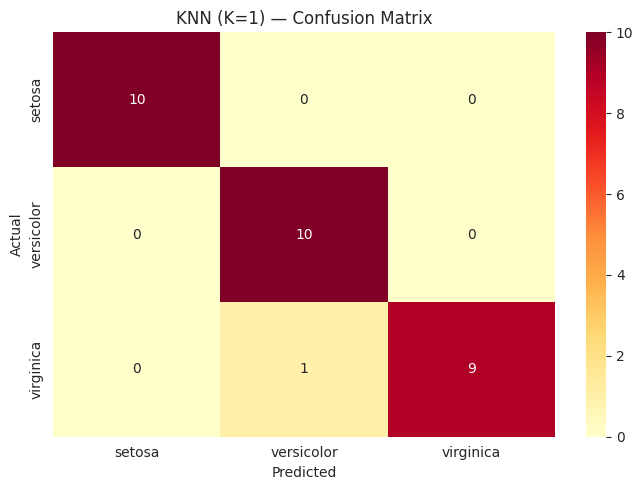

In [11]:
cm = confusion_matrix(y_test, y_pred, labels=species_names)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=species_names, yticklabels=species_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'KNN (K={best_k}) — Confusion Matrix')
plt.tight_layout()
plt.show()


## 11. Classification Report

In [12]:
print(classification_report(y_test, y_pred, target_names=species_names))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 12. Visualise the Decision Boundary (2-D)

We retrain KNN using only **petal length** and **petal width** (the two most discriminative
features) so we can plot the decision boundary in 2-D.


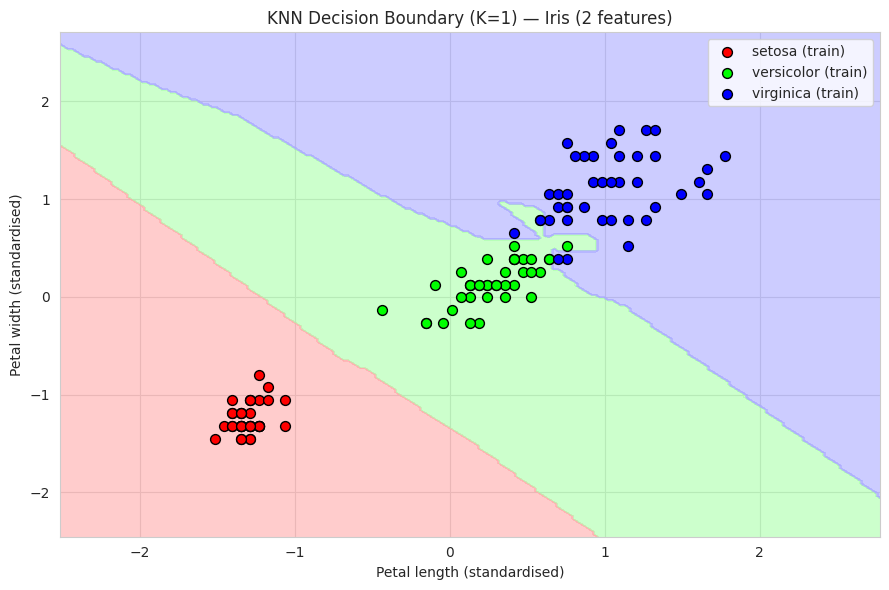

In [13]:
X_2d = data[['petal_length', 'petal_width']].values
y_2d = le.transform(data['species'])

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)
sc_2d = StandardScaler()
X_2d_train_s = sc_2d.fit_transform(X_2d_train)
X_2d_test_s  = sc_2d.transform(X_2d_test)

knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_2d_train_s, y_2d_train)

# Build mesh
x_min, x_max = X_2d_train_s[:, 0].min() - 1, X_2d_train_s[:, 0].max() + 1
y_min, y_max = X_2d_train_s[:, 1].min() - 1, X_2d_train_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold  = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
for idx, name in enumerate(species_names):
    plt.scatter(X_2d_train_s[y_2d_train == idx, 0],
                X_2d_train_s[y_2d_train == idx, 1],
                c=[cmap_bold.colors[idx]], label=f'{name} (train)',
                edgecolor='k', s=50)
plt.xlabel('Petal length (standardised)')
plt.ylabel('Petal width (standardised)')
plt.title(f'KNN Decision Boundary (K={best_k}) — Iris (2 features)')
plt.legend()
plt.tight_layout()
plt.show()


## 13. Compare Different Distance Metrics

The lab book uses the **Minkowski** distance with `p=2` (i.e. Euclidean). Other common
metrics are Manhattan (`p=1`) and Chebyshev.


In [14]:
metrics_list = [
    ('euclidean', 2),
    ('manhattan', 1),
    ('chebyshev', None),
]
rows = []
for metric, p in metrics_list:
    k = KNeighborsClassifier(n_neighbors=best_k, metric=metric, p=p)
    k.fit(X_train_scaled, y_train)
    rows.append({
        'Metric': metric,
        'Accuracy': k.score(X_test_scaled, y_test),
    })
print(pd.DataFrame(rows).round(4).to_string(index=False))


   Metric  Accuracy
euclidean    0.9667
manhattan    0.9667
chebyshev    0.9667


## 📝 Exercises

> Submit the Colab link or GitHub link or any `.ipynb` file for the exercises.

1. Use the **MNIST handwritten digits** dataset (`sklearn.datasets.load_digits`) and a KNN classifier to identify digits 0–9.
2. Calculate the Euclidean distance between a new entry and existing values given this dataset: Brightness / Saturation / Class — (40,20,Red), (50,50,Blue), (60,90,Blue), (10,25,Red), (70,70,Blue), (60,10,Red), (25,80,Blue). Predict the class of (45, 60, ?).
3. Apply **cross-validation** (`cross_val_score`) to choose K instead of a single train/test split.


---

## 📚 Key Takeaways

- **KNN** is a *lazy learner* — no training phase, just stores the data.
- **K** is a hyperparameter; odd values avoid ties, and very small K → overfitting.
- **Distance metrics:** Euclidean (default), Manhattan, Minkowski, Chebyshev, cosine.
- **Feature scaling is essential** because KNN uses distances.
- **Cost:** prediction is O(N · d) per query — slow for large datasets. Use **KD-Tree** or **Ball-Tree** for acceleration.

## 🔗 References

- Lab Activity Book (23CSE301), Department of CSE.
- Scikit-learn User Guide: <https://scikit-learn.org/stable/user_guide.html>
